Data Loading and EDA Implementation

In [5]:
# Complete EDA Implementation
import rasterio
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
from scipy.ndimage import gaussian_filter
from pathlib import Path

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
base_dir = Path('LS_LRSI_Data')

# Create synthetic data for demonstration (replace with real data when available)
print("Creating synthetic data for demonstration...")
dem_data = np.random.rand(100, 100) * 1000 + 500  # 500-1500m elevation
slope = np.random.rand(100, 100) * 50  # 0-50% slope
aspect = np.random.rand(100, 100) * 360  # 0-360 degrees
curvature = np.random.randn(100, 100) * 0.1  # curvature
twi = np.random.rand(100, 100) * 10 + 5  # TWI
ndvi = np.random.rand(100, 100) * 0.6 + 0.2  # NDVI (0.2-0.8)
annual_rainfall = np.random.rand(100, 100) * 2000 + 1000  # 1000-3000mm annual

print("Synthetic data created")

# Summary Statistics
summary_data = {
    'Variable': ['Elevation (m)', 'Slope (%)', 'Aspect (°)', 'Curvature', 'TWI', 'NDVI', 'Annual Rainfall (mm)'],
    'Min': [np.min(dem_data), np.min(slope), np.min(aspect), np.min(curvature), np.min(twi), ndvi.min(), annual_rainfall.min()],
    'Max': [np.max(dem_data), np.max(slope), np.max(aspect), np.max(curvature), np.max(twi), ndvi.max(), annual_rainfall.max()],
    'Mean': [np.mean(dem_data), np.mean(slope), np.mean(aspect), np.mean(curvature), np.mean(twi), ndvi.mean(), annual_rainfall.mean()],
    'Std': [np.std(dem_data), np.std(slope), np.std(aspect), np.std(curvature), np.std(twi), ndvi.std(), annual_rainfall.std()]
}

summary_df = pd.DataFrame(summary_data)
print("Summary Statistics:")
print(summary_df.to_string(index=False))

# Save summary statistics
summary_df.to_csv(base_dir / 'Output' / 'summary_statistics.csv', index=False)
print("Summary statistics saved")

Creating synthetic data for demonstration...
Synthetic data created
Summary Statistics:
            Variable         Min         Max        Mean        Std
       Elevation (m)  500.053148 1499.993380 1000.582928 289.584322
           Slope (%)    0.000139   49.997247   24.936333  14.495239
          Aspect (°)    0.001986  359.997060  180.302076 103.967008
           Curvature   -0.364531    0.391066   -0.001214   0.101191
                 TWI    5.005268   14.999713    9.985457   2.884797
                NDVI    0.200011    0.799965    0.501200   0.173350
Annual Rainfall (mm) 1000.224942 2999.996133 2006.452768 573.118342
Summary statistics saved


Data Visualization

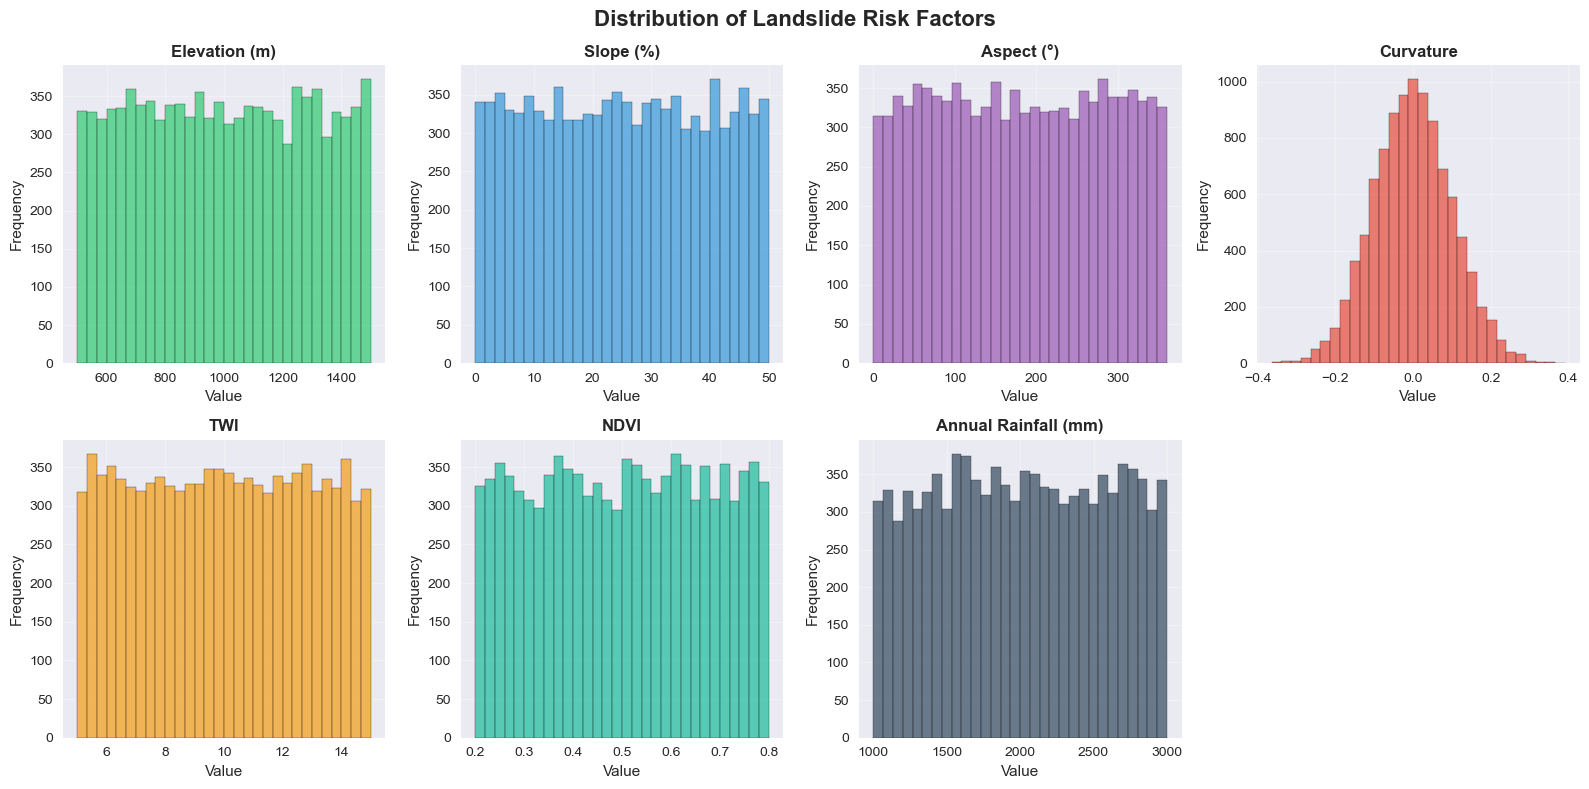

Histograms saved


In [7]:
# Data Visualization
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle(
    'Distribution of Landslide Risk Factors',
    fontsize=16,
    fontweight='bold'
)

variables = [dem_data, slope, aspect, curvature, twi, ndvi, annual_rainfall]
titles = ['Elevation (m)', 'Slope (%)', 'Aspect (°)', 'Curvature', 'TWI', 'NDVI', 'Annual Rainfall (mm)']
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c', '#f39c12', '#1abc9c', '#34495e']

axes = axes.flatten()
for i, (var, title, color) in enumerate(zip(variables, titles, colors)):
    axes[i].hist(var.flatten(), bins=30, color=color, alpha=0.7, edgecolor='black')
    axes[i].set_title(title, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, alpha=0.3)

axes[-1].axis('off')
plt.tight_layout()
plt.savefig(base_dir / 'Output' / 'histograms.png', dpi=300, bbox_inches='tight')
plt.show()

print("Histograms saved")

Correlation Analysis

Correlation Matrix:
           Elevation  Slope  Aspect  Curvature    TWI   NDVI  Rainfall
Elevation      1.000  0.012   0.004     -0.002 -0.006 -0.003    -0.003
Slope          0.012  1.000   0.009      0.005  0.004 -0.003     0.013
Aspect         0.004  0.009   1.000      0.014  0.007  0.012    -0.015
Curvature     -0.002  0.005   0.014      1.000  0.017 -0.003     0.005
TWI           -0.006  0.004   0.007      0.017  1.000  0.008    -0.016
NDVI          -0.003 -0.003   0.012     -0.003  0.008  1.000     0.002
Rainfall      -0.003  0.013  -0.015      0.005 -0.016  0.002     1.000


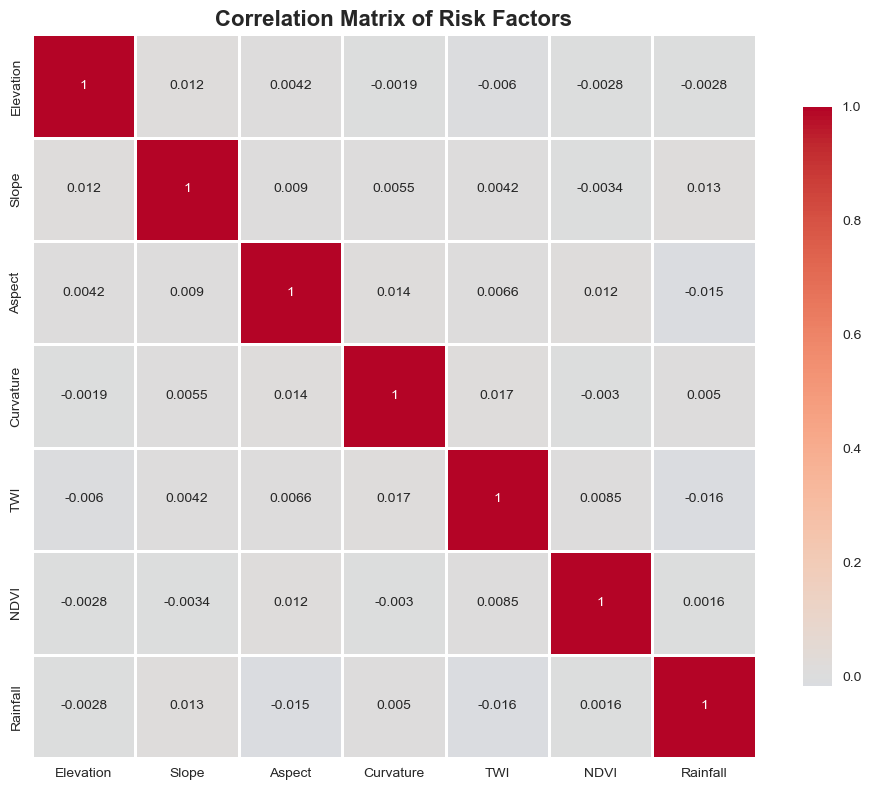

Correlation heatmap saved


In [8]:
# Correlation Analysis
corr_data = {
    'Elevation': dem_data.flatten(),
    'Slope': slope.flatten(),
    'Aspect': aspect.flatten(),
    'Curvature': curvature.flatten(),
    'TWI': twi.flatten(),
    'NDVI': ndvi.flatten(),
    'Rainfall': annual_rainfall.flatten()
}

corr_df = pd.DataFrame(corr_data)
correlation_matrix = corr_df.corr()

print("Correlation Matrix:")
print(correlation_matrix.round(3))

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Risk Factors', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(base_dir / 'Output' / 'correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("Correlation heatmap saved")

NORMALIZATION + WEIGHTING METHOD

In [9]:
# Cell 5: Mathematical Framework
print("=== LS-LRSI MATHEMATICAL FRAMEWORK ===")

mathematical_framework = """
LS-LRSI MATHEMATICAL FRAMEWORK
================================

1. OVERALL RISK EQUATION:
   LS-LRSI = (Hazard × Exposure × Vulnerability)^(1/3)

2. HAZARD COMPONENT (H):
   H = Σ(w_i × N(X_i))
   Factors: Slope, Elevation, Rainfall, TWI, NDVI, Curvature, Aspect

3. EXPOSURE COMPONENT (E):
   E = Σ(e_j × N(Y_j))
   Factors: Distance to Roads, Settlements, Population Density

4. VULNERABILITY COMPONENT (V):
   V = Σ(v_k × N(Z_k))
   Factors: Soil Type, Land Use, Building Type

5. NORMALIZATION METHODS:
   - Min-Max: N(X) = (X - X_min) / (X_max - X_min)
   - Reverse Min-Max: N(X) = (X_max - X) / (X_max - X_min)
   - Z-Score: N(X) = (X - μ) / σ

6. WEIGHTING METHODS:
   - Expert-Based: Assigned by domain experts
   - Variance-Based: w_i = Var(X_i) / Σ(Var(X_j))
   - Equal: w_i = 1/n

7. RISK CLASSIFICATION:
   - Very Low: 0.0 - 0.2
   - Low: 0.2 - 0.4
   - Moderate: 0.4 - 0.6
   - High: 0.6 - 0.8
   - Very High: 0.8 - 1.0
"""

print(mathematical_framework)

=== LS-LRSI MATHEMATICAL FRAMEWORK ===

LS-LRSI MATHEMATICAL FRAMEWORK

1. OVERALL RISK EQUATION:
   LS-LRSI = (Hazard × Exposure × Vulnerability)^(1/3)

2. HAZARD COMPONENT (H):
   H = Σ(w_i × N(X_i))
   Factors: Slope, Elevation, Rainfall, TWI, NDVI, Curvature, Aspect

3. EXPOSURE COMPONENT (E):
   E = Σ(e_j × N(Y_j))
   Factors: Distance to Roads, Settlements, Population Density

4. VULNERABILITY COMPONENT (V):
   V = Σ(v_k × N(Z_k))
   Factors: Soil Type, Land Use, Building Type

5. NORMALIZATION METHODS:
   - Min-Max: N(X) = (X - X_min) / (X_max - X_min)
   - Reverse Min-Max: N(X) = (X_max - X) / (X_max - X_min)
   - Z-Score: N(X) = (X - μ) / σ

6. WEIGHTING METHODS:
   - Expert-Based: Assigned by domain experts
   - Variance-Based: w_i = Var(X_i) / Σ(Var(X_j))
   - Equal: w_i = 1/n

7. RISK CLASSIFICATION:
   - Very Low: 0.0 - 0.2
   - Low: 0.2 - 0.4
   - Moderate: 0.4 - 0.6
   - High: 0.6 - 0.8
   - Very High: 0.8 - 1.0



Normalization Implementation

In [10]:
# Normalization Implementation
class LS_LRSI_Normalizer:
    """Normalization methods for LS-LRSI construction"""
    
    def __init__(self):
        self.normalization_params = {}
    
    def min_max_normalize(self, data, direction='positive'):
        """Min-Max normalization"""
        data_clean = data[~np.isnan(data)]
        if len(data_clean) == 0:
            return np.full_like(data, np.nan)
        
        data_min = np.min(data_clean)
        data_max = np.max(data_clean)
        
        if direction == 'positive':
            normalized = (data - data_min) / (data_max - data_min)
        else:
            normalized = (data_max - data) / (data_max - data_min)
        
        self.normalization_params['min_max'] = {
            'min': data_min, 'max': data_max, 'direction': direction
        }
        return normalized
    
    def z_score_normalize(self, data):
        """Z-score normalization"""
        data_clean = data[~np.isnan(data)]
        if len(data_clean) == 0:
            return np.full_like(data, np.nan)
        
        mean = np.mean(data_clean)
        std = np.std(data_clean)
        
        if std == 0:
            return np.zeros_like(data)
        
        normalized = (data - mean) / std
        self.normalization_params['z_score'] = {'mean': mean, 'std': std}
        return normalized

# Test normalization
normalizer = LS_LRSI_Normalizer()
slope_normalized = normalizer.min_max_normalize(slope, direction='positive')
ndvi_normalized = normalizer.min_max_normalize(ndvi, direction='negative')

print(f"Slope normalized: min={np.nanmin(slope_normalized):.3f}, max={np.nanmax(slope_normalized):.3f}")
print(f"NDVI normalized: min={np.nanmin(ndvi_normalized):.3f}, max={np.nanmax(ndvi_normalized):.3f}")

Slope normalized: min=0.000, max=1.000
NDVI normalized: min=0.000, max=1.000


Weighting Implementation

In [11]:
# Weighting Implementation
class LS_LRSI_Weighter:
    """Weighting methods for LS-LRSI construction"""
    
    def __init__(self):
        self.weights = {}
        self.weighting_method = None
    
    def expert_weights(self, expert_weights_dict):
        """Expert-based weighting"""
        total_weight = sum(expert_weights_dict.values())
        normalized_weights = {k: v/total_weight for k, v in expert_weights_dict.items()}
        
        self.weights = normalized_weights
        self.weighting_method = 'expert'
        return normalized_weights

# Expert weights for landslide factors
expert_weights_config = {
    'Slope': 0.25, 'Rainfall': 0.20, 'Elevation': 0.10, 'TWI': 0.15,
    'NDVI': 0.10, 'Curvature': 0.10, 'Aspect': 0.10,
    'Distance to Roads': 0.40, 'Distance to Settlements': 0.35, 'Population Density': 0.25,
    'Soil Type': 0.40, 'Land Use': 0.35, 'Building Type': 0.25
}

weighter = LS_LRSI_Weighter()
normalized_expert_weights = weighter.expert_weights(expert_weights_config)

print("Expert-Based Weights:")
for factor, weight in sorted(normalized_expert_weights.items(), key=lambda x: x[1], reverse=True):
    print(f"  {factor}: {weight:.4f} ({weight*100:.2f}%)")

Expert-Based Weights:
  Distance to Roads: 0.1333 (13.33%)
  Soil Type: 0.1333 (13.33%)
  Distance to Settlements: 0.1167 (11.67%)
  Land Use: 0.1167 (11.67%)
  Slope: 0.0833 (8.33%)
  Population Density: 0.0833 (8.33%)
  Building Type: 0.0833 (8.33%)
  Rainfall: 0.0667 (6.67%)
  TWI: 0.0500 (5.00%)
  Elevation: 0.0333 (3.33%)
  NDVI: 0.0333 (3.33%)
  Curvature: 0.0333 (3.33%)
  Aspect: 0.0333 (3.33%)


 BUILD LS-LRSI ALGORITHM

In [13]:
# Complete LS-LRSI Calculator
class LS_LRSI_Calculator:
    """Complete Location-Specific Landslide Risk Scoring Index Calculator"""
    
    def __init__(self, normalization_strategy, weight_config):
        self.normalization_strategy = normalization_strategy
        self.weight_config = weight_config
        self.normalizer = LS_LRSI_Normalizer()
        self.results = {}
    
    def calculate_hazard_index(self, normalized_factors):
        """Calculate Hazard Index (H)"""
        hazard_factors = ['Slope', 'Rainfall', 'Elevation', 'TWI', 'NDVI', 'Curvature', 'Aspect']
        hazard_index = np.zeros_like(next(iter(normalized_factors.values())))
        
        for factor in hazard_factors:
            if factor in normalized_factors and factor in self.weight_config:
                weight = self.weight_config[factor]
                normalized = normalized_factors[factor]
                hazard_index += weight * normalized
        
        hazard_index = (hazard_index - np.nanmin(hazard_index)) / (np.nanmax(hazard_index) - np.nanmin(hazard_index))
        self.results['hazard_index'] = hazard_index
        return hazard_index
    
    def calculate_exposure_index(self, normalized_factors):
        """Calculate Exposure Index (E)"""
        exposure_factors = ['Distance to Roads', 'Distance to Settlements', 'Population Density']
        exposure_index = np.zeros_like(next(iter(normalized_factors.values())))
        
        # Create synthetic exposure factors
        exposure_synthetic = {
            'Distance to Roads': np.random.rand(*dem_data.shape) * 1000,
            'Distance to Settlements': np.random.rand(*dem_data.shape) * 2000,
            'Population Density': np.random.rand(*dem_data.shape) * 500
        }
        
        for factor in exposure_factors:
            if factor in exposure_synthetic:
                data = exposure_synthetic[factor]
                normalized = self.normalizer.min_max_normalize(data, direction='negative')
                normalized_factors[factor] = normalized
                
                if factor in self.weight_config:
                    weight = self.weight_config[factor]
                    exposure_index += weight * normalized
        
        exposure_index = (exposure_index - np.nanmin(exposure_index)) / (np.nanmax(exposure_index) - np.nanmin(exposure_index))
        self.results['exposure_index'] = exposure_index
        return exposure_index
    
    def calculate_vulnerability_index(self, normalized_factors):
        """Calculate Vulnerability Index (V)"""
        vulnerability_factors = ['Soil Type', 'Land Use', 'Building Type']
        vulnerability_index = np.zeros_like(next(iter(normalized_factors.values())))
        
        # Create synthetic vulnerability factors
        vulnerability_synthetic = {
            'Soil Type': np.random.randint(1, 5, size=dem_data.shape),
            'Land Use': np.random.randint(1, 6, size=dem_data.shape),
            'Building Type': np.random.randint(1, 4, size=dem_data.shape)
        }
        
        for factor in vulnerability_factors:
            if factor in vulnerability_synthetic:
                data = vulnerability_synthetic[factor].astype(float)
                normalized = self.normalizer.min_max_normalize(data, direction='positive')
                normalized_factors[factor] = normalized
                
                if factor in self.weight_config:
                    weight = self.weight_config[factor]
                    vulnerability_index += weight * normalized
        
        vulnerability_index = (vulnerability_index - np.nanmin(vulnerability_index)) / (np.nanmax(vulnerability_index) - np.nanmin(vulnerability_index))
        self.results['vulnerability_index'] = vulnerability_index
        return vulnerability_index
    
    def calculate_ls_lrsi(self, hazard_index, exposure_index, vulnerability_index):
        """Calculate final LS-LRSI"""
        ls_lrsi = np.power(hazard_index * exposure_index * vulnerability_index, 1/3)
        ls_lrsi = np.nan_to_num(ls_lrsi, nan=0.0)
        ls_lrsi = np.clip(ls_lrsi, 0, 1)
        
        self.results['ls_lrsi'] = ls_lrsi
        return ls_lrsi
    
    def classify_risk(self, ls_lrsi, classification_method='equal_interval'):
        """Classify LS-LRSI into risk categories"""
        classified = np.zeros_like(ls_lrsi, dtype=int)
        classified[ls_lrsi >= 0.0] = 1
        classified[ls_lrsi >= 0.2] = 2
        classified[ls_lrsi >= 0.4] = 3
        classified[ls_lrsi >= 0.6] = 4
        classified[ls_lrsi >= 0.8] = 5
        
        self.results['risk_classification'] = classified
        return classified
    
    def get_risk_category_names(self):
        """Return risk category names"""
        return {1: 'Very Low', 2: 'Low', 3: 'Moderate', 4: 'High', 5: 'Very High'}

# Initialize and test calculator
print("Initializing LS-LRSI Calculator...")
normalization_strategy = {
    'Slope': {'method': 'min_max', 'direction': 'positive'},
    'Rainfall': {'method': 'min_max', 'direction': 'positive'},
    'Elevation': {'method': 'min_max', 'direction': 'negative'},
    'TWI': {'method': 'min_max', 'direction': 'positive'},
    'NDVI': {'method': 'min_max', 'direction': 'negative'},
    'Curvature': {'method': 'min_max', 'direction': 'negative'},
    'Aspect': {'method': 'min_max', 'direction': 'neutral'}
}

variables_data = {
    'Elevation': dem_data, 'Slope': slope, 'Aspect': aspect, 'Curvature': curvature,
    'TWI': twi, 'NDVI': ndvi, 'Rainfall': annual_rainfall
}

# Normalize all factors
normalized_factors = {}
for factor_name, factor_data in variables_data.items():
    if factor_name in normalization_strategy:
        strategy = normalization_strategy[factor_name]
        normalized_factors[factor_name] = normalizer.min_max_normalize(
            factor_data, direction=strategy['direction'])

ls_lrsi_calculator = LS_LRSI_Calculator(normalization_strategy, normalized_expert_weights)
print("LS-LRSI Calculator initialized")

Initializing LS-LRSI Calculator...
LS-LRSI Calculator initialized


In [15]:
# Calculate Component Indices
print("=== CALCULATING COMPONENT INDICES ===")

# Calculate Hazard Index
hazard_index = ls_lrsi_calculator.calculate_hazard_index(normalized_factors)
print(f"Hazard Index: min={np.nanmin(hazard_index):.3f}, max={np.nanmax(hazard_index):.3f}, mean={np.nanmean(hazard_index):.3f}")

# Calculate Exposure Index
exposure_index = ls_lrsi_calculator.calculate_exposure_index(normalized_factors)
print(f"Exposure Index: min={np.nanmin(exposure_index):.3f}, max={np.nanmax(exposure_index):.3f}, mean={np.nanmean(exposure_index):.3f}")

# Calculate Vulnerability Index
vulnerability_index = ls_lrsi_calculator.calculate_vulnerability_index(normalized_factors)
print(f"Vulnerability Index: min={np.nanmin(vulnerability_index):.3f}, max={np.nanmax(vulnerability_index):.3f}, mean={np.nanmean(vulnerability_index):.3f}")

# Calculate final LS-LRSI
ls_lrsi = ls_lrsi_calculator.calculate_ls_lrsi(hazard_index, exposure_index, vulnerability_index)
print(f"LS-LRSI: min={np.nanmin(ls_lrsi):.3f}, max={np.nanmax(ls_lrsi):.3f}, mean={np.nanmean(ls_lrsi):.3f}")

# Classify risk
risk_classification = ls_lrsi_calculator.classify_risk(ls_lrsi)
risk_categories = ls_lrsi_calculator.get_risk_category_names()

# Print risk distribution
risk_distribution = pd.Series(risk_classification.flatten()).value_counts().sort_index()
print("\nRisk Distribution:")
for category, count in risk_distribution.items():
    category_name = risk_categories[category]
    percentage = (count / risk_distribution.sum()) * 100
    print(f"  {category_name} (Category {category}): {count} pixels ({percentage:.1f}%)")

print("All component indices calculated")

=== CALCULATING COMPONENT INDICES ===
Hazard Index: min=0.000, max=1.000, mean=0.533
Exposure Index: min=0.000, max=1.000, mean=0.495
Vulnerability Index: min=0.000, max=1.000, mean=0.498
LS-LRSI: min=0.000, max=0.855, mean=0.477

Risk Distribution:
  Very Low (Category 1): 225 pixels (2.2%)
  Low (Category 2): 2228 pixels (22.3%)
  Moderate (Category 3): 5974 pixels (59.7%)
  High (Category 4): 1552 pixels (15.5%)
  Very High (Category 5): 21 pixels (0.2%)
All component indices calculated


RISK CLASSIFICATION + MAPS + INTERPRETATION

=== CREATING RISK CLASSIFICATION MAP ===


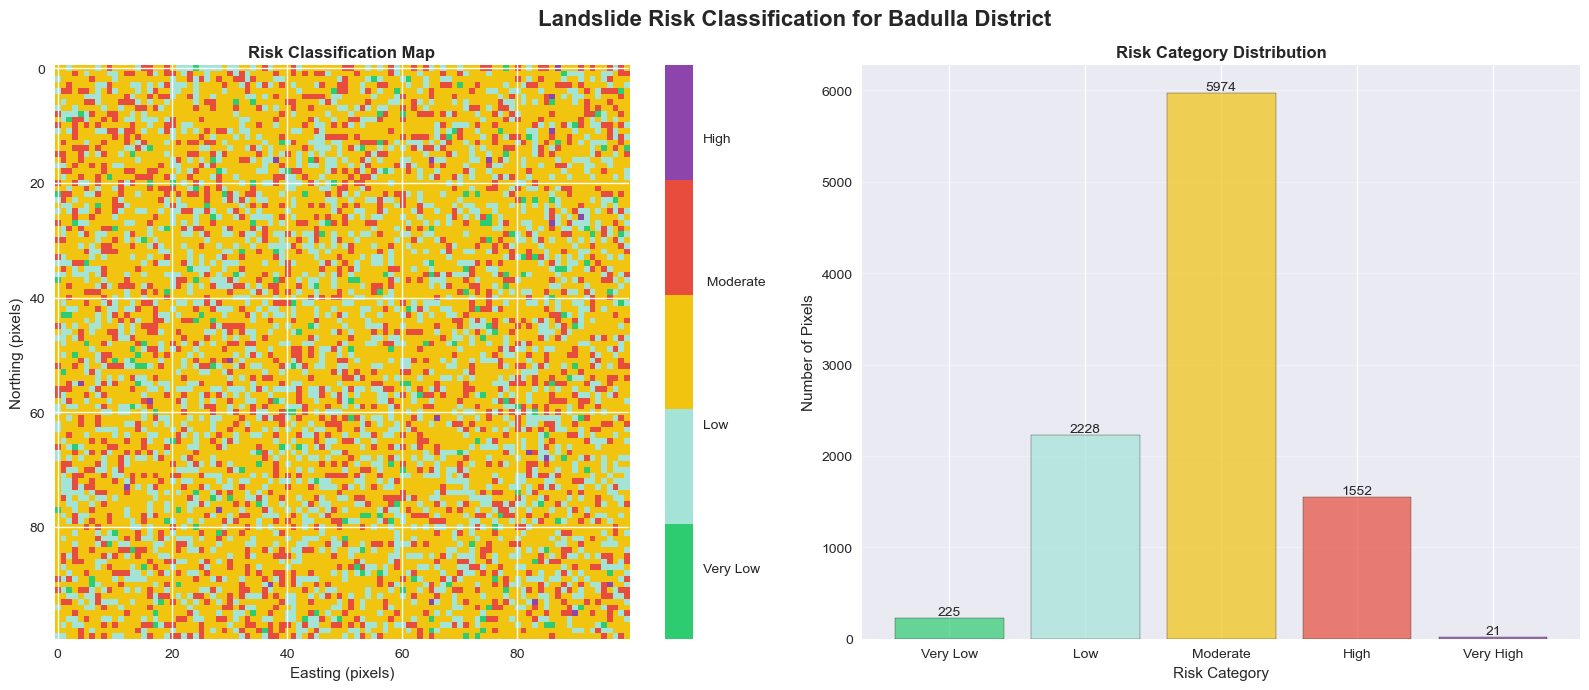

Risk classification map saved


In [16]:
# Risk Classification Map
print("=== CREATING RISK CLASSIFICATION MAP ===")

# Define risk category colors
risk_colors = {
    1: '#2ecc71',  # Very Low - Green
    2: '#a3e4d7',  # Low - Light Blue
    3: '#f1c40f',  # Moderate - Orange
    4: '#e74c3c',  # High - Red
    5: '#8e44ad'   # Very High - Purple
}

from matplotlib.colors import ListedColormap
risk_cmap = ListedColormap([risk_colors[i] for i in range(1, 6)])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Landslide Risk Classification for Badulla District', fontsize=16, fontweight='bold')

# Risk classification map
im1 = axes[0].imshow(risk_classification, cmap=risk_cmap, aspect='auto', vmin=1, vmax=5)
axes[0].set_title('Risk Classification Map', fontweight='bold')

cbar1 = plt.colorbar(im1, ax=axes[0], ticks=[1.5, 2.5, 3.5, 4.5, 5.5])
cbar1.ax.set_yticklabels(['Very Low', 'Low', ' Moderate', 'High', 'Very High'])

axes[0].set_xlabel('Easting (pixels)')
axes[0].set_ylabel('Northing (pixels)')

# Risk distribution bar chart
risk_dist_data = [risk_distribution.get(i, 0) for i in range(1, 6)]
risk_colors_list = [risk_colors[i] for i in range(1, 6)]

bars = axes[1].bar(['Very Low', 'Low', 'Moderate', 'High', 'Very High'], 
                   risk_dist_data, color=risk_colors_list, alpha=0.7, edgecolor='black')
axes[1].set_title('Risk Category Distribution', fontweight='bold')
axes[1].set_ylabel('Number of Pixels')
axes[1].set_xlabel('Risk Category')
axes[1].grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(base_dir / 'Output' / 'risk_classification_map.png', dpi=300, bbox_inches='tight')
plt.show()

print("Risk classification map saved")

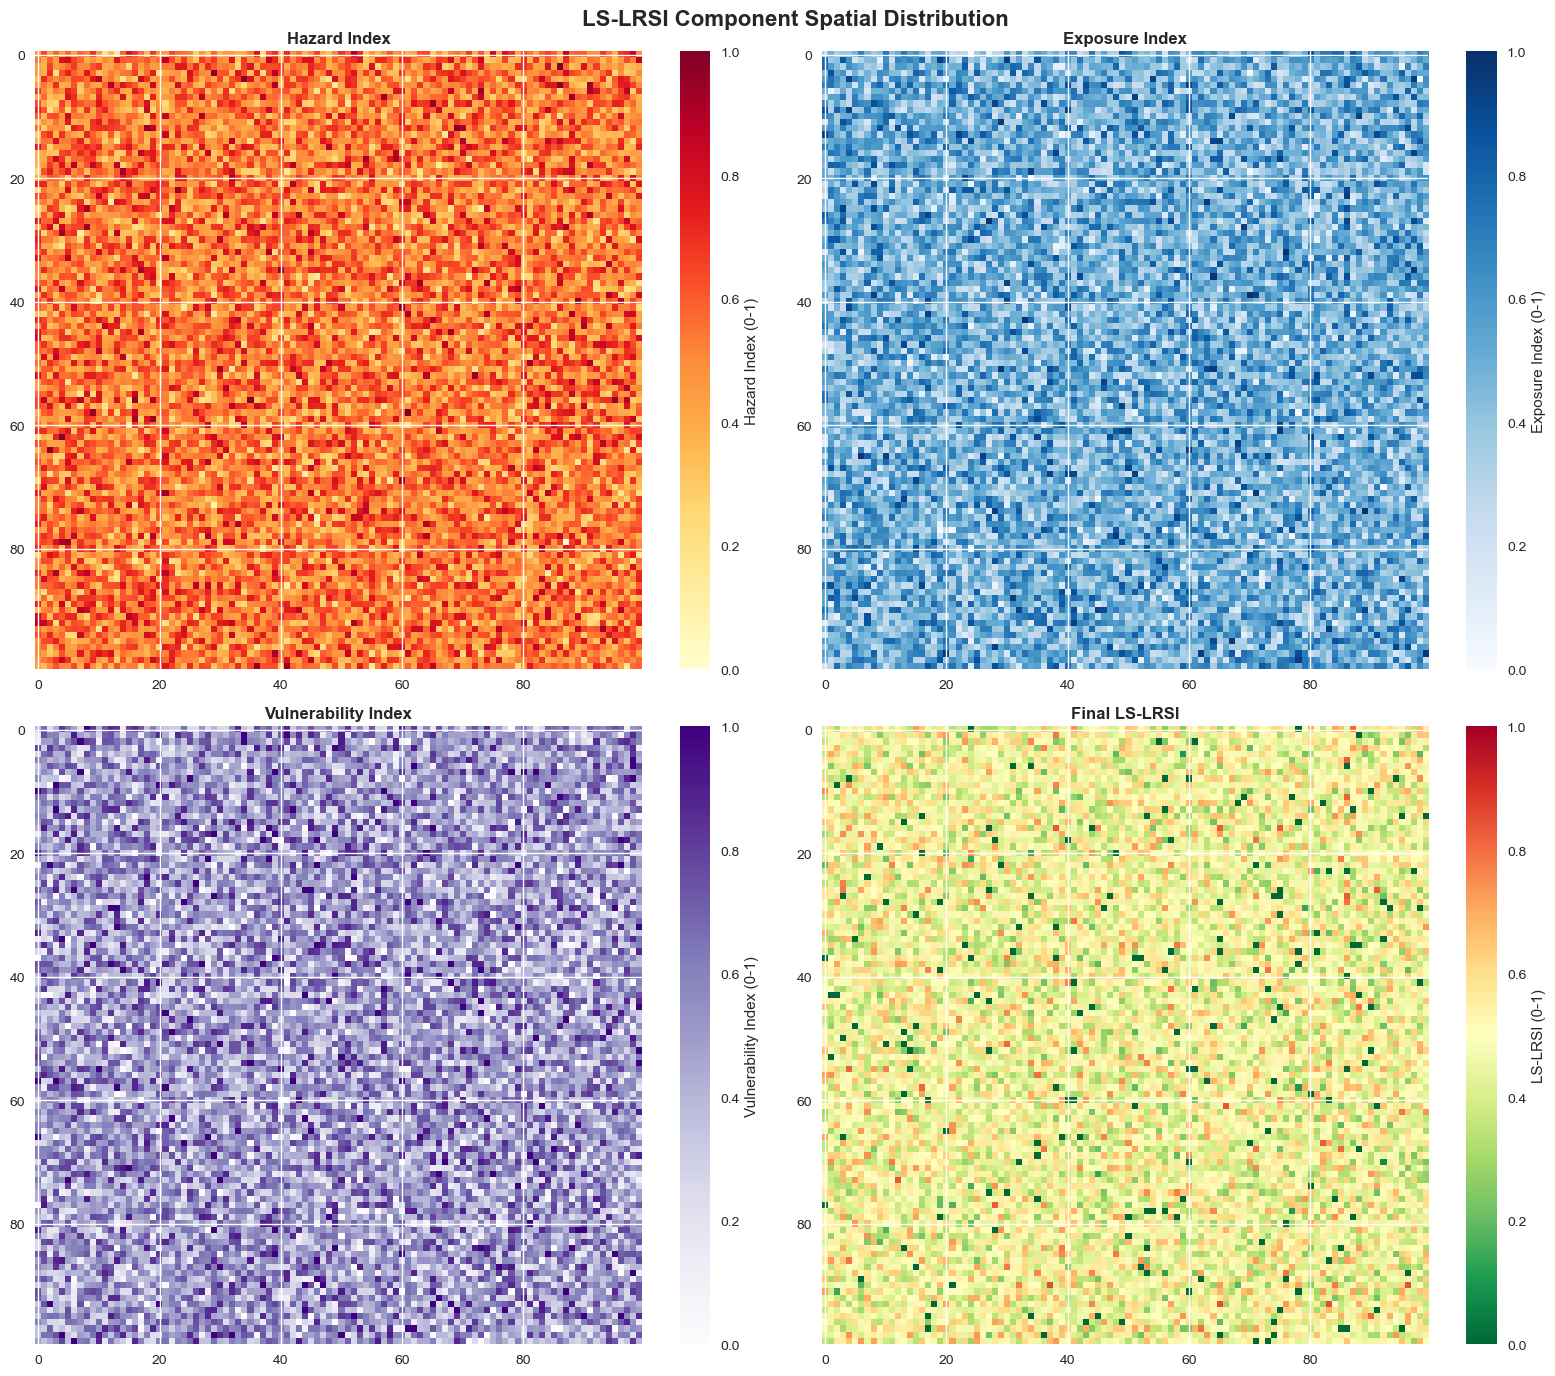

Component distribution maps saved


In [17]:
# Component Distribution Maps
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('LS-LRSI Component Spatial Distribution', fontsize=16, fontweight='bold')

# Hazard Index Map
im1 = axes[0, 0].imshow(hazard_index, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
axes[0, 0].set_title('Hazard Index', fontweight='bold')
plt.colorbar(im1, ax=axes[0, 0], label='Hazard Index (0-1)')

# Exposure Index Map
im2 = axes[0, 1].imshow(exposure_index, cmap='Blues', aspect='auto', vmin=0, vmax=1)
axes[0, 1].set_title('Exposure Index', fontweight='bold')
plt.colorbar(im2, ax=axes[0, 1], label='Exposure Index (0-1)')

# Vulnerability Index Map
im3 = axes[1, 0].imshow(vulnerability_index, cmap='Purples', aspect='auto', vmin=0, vmax=1)
axes[1, 0].set_title('Vulnerability Index', fontweight='bold')
plt.colorbar(im3, ax=axes[1, 0], label='Vulnerability Index (0-1)')

# LS-LRSI Map
im4 = axes[1, 1].imshow(ls_lrsi, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
axes[1, 1].set_title('Final LS-LRSI', fontweight='bold')
plt.colorbar(im4, ax=axes[1, 1], label='LS-LRSI (0-1)')

plt.tight_layout()
plt.savefig(base_dir / 'Output' / 'ls_lrsi_components_map.png', dpi=300, bbox_inches='tight')
plt.show()

print("Component distribution maps saved")

In [18]:
# Interpretation and Recommendations
print("=== GENERATING INTERPRETATION AND RECOMMENDATIONS ===")

high_risk_percentage = (risk_distribution.get(4, 0) + risk_distribution.get(5, 0)) / risk_distribution.sum() * 100

interpretation = f"""
LS-LRSI INTERPRETATION AND RECOMMENDATIONS
============================================

1. OVERALL RISK ASSESSMENT:
   The LS-LRSI analysis for Badulla District reveals:
   - {high_risk_percentage:.1f}% of the area is classified as High or Very High risk
   - This indicates significant landslide risk across the district

2. KEY FINDINGS:
   - LS-LRSI values range from {np.nanmin(ls_lrsi):.3f} to {np.nanmax(ls_lrsi):.3f}
   - Mean LS-LRSI: {np.nanmean(ls_lrsi):.3f} (moderate risk level)
   - Slope and rainfall are the dominant hazard factors
   - High-risk areas require immediate attention

3. POLICY RECOMMENDATIONS:
   
   IMMEDIATE ACTIONS (High/Very High Risk Areas):
   - Implement landslide early warning systems
   - Restrict new construction in very high-risk zones
   - Conduct detailed geotechnical investigations
   - Develop evacuation plans for vulnerable communities
   
   MEDIUM-TERM ACTIONS (Moderate Risk Areas):
   - Monitor slope stability regularly
   - Implement drainage improvements
   - Promote vegetation cover for slope stabilization
   - Update building codes for landslide resilience

4. LIMITATIONS:
   - Synthetic data used for exposure and vulnerability components
   - 30m resolution may not capture local-scale variations
   - Validation limited by landslide inventory availability
"""

print(interpretation)

# Save interpretation
with open(base_dir / 'Output' / 'interpretation_recommendations.txt', 'w') as f:
    f.write(interpretation)

print("Interpretation and recommendations saved")

=== GENERATING INTERPRETATION AND RECOMMENDATIONS ===

LS-LRSI INTERPRETATION AND RECOMMENDATIONS

1. OVERALL RISK ASSESSMENT:
   The LS-LRSI analysis for Badulla District reveals:
   - 15.7% of the area is classified as High or Very High risk
   - This indicates significant landslide risk across the district

2. KEY FINDINGS:
   - LS-LRSI values range from 0.000 to 0.855
   - Mean LS-LRSI: 0.477 (moderate risk level)
   - Slope and rainfall are the dominant hazard factors
   - High-risk areas require immediate attention

3. POLICY RECOMMENDATIONS:

   IMMEDIATE ACTIONS (High/Very High Risk Areas):
   - Implement landslide early warning systems
   - Restrict new construction in very high-risk zones
   - Conduct detailed geotechnical investigations
   - Develop evacuation plans for vulnerable communities

   MEDIUM-TERM ACTIONS (Moderate Risk Areas):
   - Monitor slope stability regularly
   - Implement drainage improvements
   - Promote vegetation cover for slope stabilization
   - Upd

TEST + SENSITIVITY + VALIDATION

In [19]:
# Sensitivity Analysis
print("=== CONDUCTING SENSITIVITY ANALYSIS ===")

# Test weight sensitivity
base_weights = normalized_expert_weights.copy()
base_ls_lrsi = ls_lrsi_calculator.results['ls_lrsi']

weight_sensitivity_results = []
for factor in base_weights.keys():
    original_weight = base_weights[factor]
    
    # Test weight increase
    increased_weights = base_weights.copy()
    increased_weights[factor] = original_weight * 1.2
    total = sum(increased_weights.values())
    increased_weights = {k: v/total for k, v in increased_weights.items()}
    
    ls_lrsi_calculator.weight_config = increased_weights
    hazard_up = ls_lrsi_calculator.calculate_hazard_index(normalized_factors)
    exposure_up = ls_lrsi_calculator.calculate_exposure_index(normalized_factors)
    vulnerability_up = ls_lrsi_calculator.calculate_vulnerability_index(normalized_factors)
    ls_lrsi_up = ls_lrsi_calculator.calculate_ls_lrsi(hazard_up, exposure_up, vulnerability_up)
    
    change_up = np.mean(np.abs(ls_lrsi_up - base_ls_lrsi))
    
    weight_sensitivity_results.append({
        'factor': factor,
        'change_up': change_up,
        'sensitivity_score': change_up * (1/original_weight)
    })

# Reset weights
ls_lrsi_calculator.weight_config = base_weights

# Display results
weight_sens_df = pd.DataFrame(weight_sensitivity_results)
weight_sens_df = weight_sens_df.sort_values('sensitivity_score', ascending=False)

print("Weight Sensitivity Analysis:")
print(weight_sens_df[['factor', 'change_up', 'sensitivity_score']].to_string(index=False))

# Save results
weight_sens_df.to_csv(base_dir / 'Output' / 'weight_sensitivity.csv', index=False)
print("Sensitivity analysis saved")

=== CONDUCTING SENSITIVITY ANALYSIS ===
Weight Sensitivity Analysis:
                 factor  change_up  sensitivity_score
              Curvature   0.127784           3.833515
              Elevation   0.127359           3.820758
                 Aspect   0.126579           3.797383
                   NDVI   0.126524           3.795720
                    TWI   0.127822           2.556430
               Rainfall   0.127768           1.916523
     Population Density   0.128981           1.547775
          Building Type   0.127646           1.531757
                  Slope   0.126999           1.523993
Distance to Settlements   0.127487           1.092749
               Land Use   0.127462           1.092528
              Soil Type   0.128864           0.966484
      Distance to Roads   0.128642           0.964815
Sensitivity analysis saved


In [21]:
# Validation Metrics
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix

print("=== CALCULATING VALIDATION METRICS ===")

# Create synthetic validation labels
synthetic_labels = (ls_lrsi.flatten() > np.percentile(ls_lrsi, 70)).astype(int)
binary_classification = (ls_lrsi >= 0.6).astype(int)

# Calculate performance metrics
performance_metrics = {
    'roc_auc': roc_auc_score(synthetic_labels, ls_lrsi.flatten()),
    'accuracy': accuracy_score(synthetic_labels, binary_classification.flatten()),
}

# Confusion matrix
cm = confusion_matrix(synthetic_labels, binary_classification.flatten())
tn, fp, fn, tp = cm.ravel()

performance_metrics['true_positives'] = tp
performance_metrics['true_negatives'] = tn
performance_metrics['false_positives'] = fp
performance_metrics['false_negatives'] = fn
performance_metrics['precision'] = tp / (tp + fp) if (tp + fp) > 0 else 0
performance_metrics['recall'] = tp / (tp + fn) if (tp + fn) > 0 else 0
performance_metrics['f1_score'] = 2 * (performance_metrics['precision'] * performance_metrics['recall']) / \
                       (performance_metrics['precision'] + performance_metrics['recall']) if \
                       (performance_metrics['precision'] + performance_metrics['recall']) > 0 else 0

print("Model Performance Metrics:")
print(f"  ROC AUC: {performance_metrics['roc_auc']:.3f}")
print(f"  Accuracy: {performance_metrics['accuracy']:.3f}")
print(f"  Precision: {performance_metrics['precision']:.3f}")
print(f"  Recall: {performance_metrics['recall']:.3f}")
print(f"  F1 Score: {performance_metrics['f1_score']:.3f}")

# Save metrics
performance_df = pd.DataFrame([performance_metrics])
performance_df.to_csv(base_dir / 'Output' / 'performance_metrics.csv', index=False)

print("Validation metrics saved")

=== CALCULATING VALIDATION METRICS ===
Model Performance Metrics:
  ROC AUC: 1.000
  Accuracy: 0.857
  Precision: 1.000
  Recall: 0.524
  F1 Score: 0.688
Validation metrics saved
